# Arctic sea ice volume time series

**Summary**: Pan-Arctic and inner-Arctic-Ocean sea ice volume (km³) from IS2SMGPSIT-V1, computed from precomputed scalars and cross-checked against from-grid calculations.

**Author**: Alek Petty  
**Version history**: Version 1 (08/2026)


# Import notebook dependencies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

from utils.read_data_utils import read_is2smgpsitv1_zarr

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.filterwarnings('ignore')

In [2]:
mpl.rcParams.update({
    'text.usetex': False,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stixsans',
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})
mpl.rcParams['font.sans-serif'] = ['Arial']

## Load IS2SMGPSIT-V1 and compute pan-Arctic volume

Pan-Arctic volume is summed from the gridded thickness field over all cells **except** the Canadian Arctic Archipelago (NSIDC region 12). The Zarr now includes CAA grid cells, but we exclude them from pan-Arctic totals for consistency with earlier volume budgets. Inner-Arctic-Ocean volume uses NSIDC regions 1–5 only.


In [3]:
from utils.read_data_utils import is2smgpsit_domain_masks

IS2_SMOS_SMAP = read_is2smgpsitv1_zarr(persist=False, load_cache=True)

_masks = is2smgpsit_domain_masks(IS2_SMOS_SMAP)
mask_pan_arctic = _masks['pan_arctic']
mask_iao = _masks['iao']
innerArctic = [1, 2, 3, 4, 5]

thick = IS2_SMOS_SMAP['ice_thickness'].where(IS2_SMOS_SMAP['ice_thickness'] > -1e-10)
area = IS2_SMOS_SMAP['grid_cell_area'] if 'grid_cell_area' in IS2_SMOS_SMAP else None

if area is not None:
    vol_cells_pa = (thick * area).where(mask_pan_arctic)
    volume_fused_daily = (vol_cells_pa.sum(dim=['y', 'x']) * 1e-9).load()
else:
    cell_km2 = 25.0 * 25.0
    volume_fused_daily = (
        (thick * 1e-3 * cell_km2).where(mask_pan_arctic).sum(dim=['y', 'x'])
    ).load()

volume_fused_monthly = volume_fused_daily.resample(time='1ME').mean()
_ft = pd.to_datetime(volume_fused_monthly.time.values)
volume_fused_monthly = volume_fused_monthly.assign_coords(
    time=(_ft.to_period('M').to_timestamp(how='start') + pd.Timedelta(days=14)).values
).load()

# Optional: compare with precomputed total_sea_ice_volume (includes CAA if present)
if 'total_sea_ice_volume' in IS2_SMOS_SMAP:
    _vol_pre = IS2_SMOS_SMAP['total_sea_ice_volume'].load()
    print('Precomputed total_sea_ice_volume (may include CAA):',
          f'{float(_vol_pre.min()):,.0f}-{float(_vol_pre.max()):,.0f} km^3')

print('IS2SMGPSIT-V1 pan-Arctic volume excl. CAA (km^3), daily and monthly:')
print('Daily:', volume_fused_daily.sizes['time'], 'steps,',
      f'range {float(volume_fused_daily.min()):,.0f}-{float(volume_fused_daily.max()):,.0f} km^3')
print('Monthly:', volume_fused_monthly.sizes['time'], 'steps')


Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20181101-20250430.zarr
Precomputed total_sea_ice_volume (may include CAA): 2,072-21,417 km^3
IS2SMGPSIT-V1 pan-Arctic volume excl. CAA (km^3), daily and monthly:
Daily: 1635 steps, range 1,801-19,448 km^3
Monthly: 78 steps


## Cross-check: grid sum vs precomputed field

The primary pan-Arctic series above excludes CAA (region 12). The cell below recomputes volume over the full valid grid (including CAA) for comparison with the precomputed `total_sea_ice_volume` field (which sums **all** valid cells, including CAA).

IAO volume uses the precomputed `total_sea_ice_volume_regions_1_5` scalar (NSIDC regions 1–5), cross-checked against a from-grid sum.

Grid-cell `ice_thickness` is documented as the **mean thickness across the grid cell** (open water contributes ~0 m), not an ice-only average over floes.


In [4]:
if area is not None:
    vol_cells_full = thick * area
    volume_computed_daily = (vol_cells_full.sum(dim=['y', 'x']) * 1e-9).load()
else:
    volume_computed_daily = (thick * 1e-3 * cell_km2).sum(dim=['y', 'x']).load()

volume_computed_monthly = volume_computed_daily.resample(time='1ME').mean()
_ft = pd.to_datetime(volume_computed_monthly.time.values)
volume_computed_monthly = volume_computed_monthly.assign_coords(
    time=(_ft.to_period('M').to_timestamp(how='start') + pd.Timedelta(days=14)).values
).load()

print('Full-grid volume incl. CAA (km^3):')
print('Daily:', volume_computed_daily.sizes['time'], 'steps,',
      f'range {float(volume_computed_daily.min()):,.0f}-{float(volume_computed_daily.max()):,.0f} km^3')

if 'total_sea_ice_volume' in IS2_SMOS_SMAP:
    _vol_pre = IS2_SMOS_SMAP['total_sea_ice_volume'].load()
    _diff = (volume_computed_daily - _vol_pre).load()
    _pct = 100 * _diff / _vol_pre
    print('\nCross-check vs precomputed total_sea_ice_volume (full grid, incl. CAA):')
    print(f'  max |diff|: {float(abs(_diff).max()):.2f} km³')
    print(f'  mean |diff|: {float(abs(_diff).mean()):.2f} km³ ({float(abs(_pct).mean()):.3f}%)')
    print('  (Differences are float32 rounding; field definition matches grid sum.)')
    _caa_vol = (volume_computed_daily - volume_fused_daily).load()
    print(f'  Mean CAA contribution (full − excl. CAA): {float(_caa_vol.mean()):,.0f} km³')


Full-grid volume incl. CAA (km^3):
Daily: 1635 steps, range 2,076-21,424 km^3

Cross-check vs precomputed total_sea_ice_volume (full grid, incl. CAA):
  max |diff|: 92.43 km³
  mean |diff|: 13.93 km³ (0.176%)
  (Differences are float32 rounding; field definition matches grid sum.)
  Mean CAA contribution (full − excl. CAA): 1,099 km³


In [5]:
# Inner Arctic Ocean volume (NSIDC regions 1–5)
# Prefer precomputed scalar; fall back to grid sum if absent.
from utils.read_data_utils import is2smgpsit_monthly_midmonth, area_weighted_spatial_mean

if 'total_sea_ice_volume_regions_1_5' in IS2_SMOS_SMAP:
    volume_fused_daily_iao = IS2_SMOS_SMAP['total_sea_ice_volume_regions_1_5'].load()
    print('IAO volume from precomputed total_sea_ice_volume_regions_1_5')
else:
    if area is not None:
        vol_cells_iao = (thick * area).where(mask_iao)
        volume_fused_daily_iao = (vol_cells_iao.sum(dim=['y', 'x']) * 1e-9).load()
    else:
        volume_fused_daily_iao = (
            (thick * 1e-3 * cell_km2).where(mask_iao).sum(dim=['y', 'x'])
        ).load()
    print('IAO volume from grid sum (scalar not in dataset)')

volume_fused_monthly_iao = is2smgpsit_monthly_midmonth(volume_fused_daily_iao).load()

print('IS2SMGPSIT-V1 Inner Arctic Ocean volume (km^3):')
print(f'  Daily:   {volume_fused_daily_iao.sizes["time"]} steps, '
      f'range {float(volume_fused_daily_iao.min()):,.0f}-{float(volume_fused_daily_iao.max()):,.0f} km^3')
print(f'  Monthly: {volume_fused_monthly_iao.sizes["time"]} steps, '
      f'range {float(volume_fused_monthly_iao.min()):,.0f}-{float(volume_fused_monthly_iao.max()):,.0f} km^3')

# Cross-check vs grid sum
if area is not None:
    _vol_grid_iao = ((thick * area).where(mask_iao).sum(['y', 'x']) * 1e-9).load()
    _diff_iao = (volume_fused_daily_iao - _vol_grid_iao).load()
    print('\nIAO volume sanity check vs grid sum (thick × area over regions 1–5):')
    print(f'  max |diff|: {float(abs(_diff_iao).max()):.4f} km³')
    print(f'  mean |diff|: {float(abs(_diff_iao).mean()):.4f} km³')


IAO volume from precomputed total_sea_ice_volume_regions_1_5
IS2SMGPSIT-V1 Inner Arctic Ocean volume (km^3):
  Daily:   1635 steps, range 1,645-14,974 km^3
  Monthly: 78 steps, range 2,639-14,563 km^3

IAO volume sanity check vs grid sum (thick × area over regions 1–5):
  max |diff|: 8.8423 km³
  mean |diff|: 1.2448 km³


In [6]:
# Inner Arctic Ocean mean thickness (NSIDC regions 1–5)
# Use precomputed area-weighted scalar from the Zarr (matches grid calc to ~1 cm).
from utils.read_data_utils import is2smgpsit_monthly_midmonth, area_weighted_spatial_mean

thick_mean_daily_iao = IS2_SMOS_SMAP['mean_sea_ice_thickness_regions_1_5'].load()
thick_mean_monthly_iao = is2smgpsit_monthly_midmonth(thick_mean_daily_iao).load()

_thick_grid_iao = area_weighted_spatial_mean(thick, mask_iao, area).load()
_thick_diff = (thick_mean_daily_iao - _thick_grid_iao).load()
print('IS2SMGPSIT-V1 IAO mean thickness — mean_sea_ice_thickness_regions_1_5 (m):')
print(f'  Daily:   {thick_mean_daily_iao.sizes["time"]} steps, '
      f'range {float(thick_mean_daily_iao.min()):.3f}-{float(thick_mean_daily_iao.max()):.3f}')
print(f'  Monthly: {thick_mean_monthly_iao.sizes["time"]} steps, '
      f'range {float(thick_mean_monthly_iao.min()):.3f}-{float(thick_mean_monthly_iao.max()):.3f}')
print(f'  Cross-check vs grid area-weighted mean: mean |diff| = '
      f'{float(abs(_thick_diff).mean()):.4f} m, max |diff| = {float(abs(_thick_diff).max()):.4f} m')


IS2SMGPSIT-V1 IAO mean thickness — mean_sea_ice_thickness_regions_1_5 (m):
  Daily:   1635 steps, range 0.229-2.087
  Monthly: 78 steps, range 0.368-2.030
  Cross-check vs grid area-weighted mean: mean |diff| = 0.0106 m, max |diff| = 0.0168 m


## Optional CS-2/SMOS v206 comparison data

The CS-2/SMOS v206 IAO CSV is retained for optional exploratory overlays. Set `SHOW_CS2SMOS = True` below to include it; published figures leave it off because differing spatial coverage and concentration filtering prevent a like-for-like comparison.


In [7]:
SHOW_CS2SMOS = False

# Load AWI CryoSat-2/SMOS (v206) Inner Arctic Ocean monthly time series
# CSV columns: time, sea_ice_volume (10^5 km^3), sea_ice_volume_uncertainty (10^5 km^3),
#              mean_sea_ice_thickness (m), sea_ice_extent / sea_ice_area (10^8 km^2), ...
awi_csv = './data/cs2smos-timeseries-v206-monthly-is2domain.csv'
awi_df = pd.read_csv(awi_csv, parse_dates=['time']).sort_values('time').reset_index(drop=True)
# Restrict to the IS2SMGPSIT-V1 time range (Nov 2018 onwards) for like-for-like comparison
awi_df = awi_df[awi_df['time'] >= pd.Timestamp('2018-09-01')].reset_index(drop=True)

# Convert reported scaled units to physical units (km^3 and m)
awi_time = awi_df['time'].values
volume_awi = xr.DataArray(
    awi_df['sea_ice_volume'].values * 1.0e5,
    dims='time', coords={'time': awi_time},
    name='volume_awi',
    attrs={'units': 'km^3',
           'description': 'CryoSat-2/SMOS v206 monthly sea ice volume, IS2 inner Arctic Ocean domain'},
)
volume_awi_unc = xr.DataArray(
    awi_df['sea_ice_volume_uncertainty'].values * 1.0e5,
    dims='time', coords={'time': awi_time}, name='volume_awi_unc',
    attrs={'units': 'km^3'},
)
thickness_awi = xr.DataArray(
    awi_df['mean_sea_ice_thickness'].values,
    dims='time', coords={'time': awi_time}, name='thickness_awi',
    attrs={'units': 'm',
           'description': 'CryoSat-2/SMOS v206 monthly mean sea ice thickness, IS2 IAO domain'},
)


# Break lines across melt season (May–Aug)
_cs2_month = pd.to_datetime(awi_time).month
_cs2_melt = np.isin(_cs2_month, [5, 6, 7, 8])
volume_awi = volume_awi.where(~_cs2_melt)
thickness_awi = thickness_awi.where(~_cs2_melt)
print(f'CS-2/SMOS v206 IAO loaded: {len(awi_time)} months '
      f'({pd.Timestamp(awi_time[0]):%Y-%m-%d} to {pd.Timestamp(awi_time[-1]):%Y-%m-%d})')
print(f'  Volume range:    {float(volume_awi.min()):,.0f} - {float(volume_awi.max()):,.0f} km^3')
print(f'  Thickness range: {float(thickness_awi.min()):.2f} - {float(thickness_awi.max()):.2f} m')


CS-2/SMOS v206 IAO loaded: 38 months (2018-10-25 to 2023-12-12)
  Volume range:    4,200 - 13,900 km^3
  Thickness range: 0.83 - 1.99 m


In [8]:
volume_fused_daily.time.values

array(['2018-11-01T00:00:00.000000000', '2018-11-02T00:00:00.000000000',
       '2018-11-03T00:00:00.000000000', ...,
       '2025-04-28T00:00:00.000000000', '2025-04-29T00:00:00.000000000',
       '2025-04-30T00:00:00.000000000'], dtype='datetime64[ns]')

## Arctic sea ice volume: raw and seasonal anomalies

Two-panel IS2SMGPSIT-V1 time series: **(a)** raw pan-Arctic and inner-Arctic-Ocean (NSIDC regions 1–5) volume (daily line + monthly markers); **(b)** pan-Arctic and inner-Arctic daily seasonal anomalies after removing the calendar climatology (no monthly). Summers (May–August) are shaded; daily series are masked in summer. An optional CS-2/SMOS overlay is controlled by `SHOW_CS2SMOS`.



Sea ice volume — IS2SMGPSIT-V1 (write-up)
--- Pan-Arctic: monthly means (km³) ---
  monthly mean volume   2018-11-15   8,469.88 km³
  monthly mean volume   2018-12-15   11,525.55 km³
  monthly mean volume   2019-01-15   14,712.89 km³
  monthly mean volume   2019-02-15   17,303.84 km³
  monthly mean volume   2019-03-15   18,805.71 km³
  monthly mean volume   2019-04-15   18,725.46 km³
  monthly mean volume   2019-09-15   3,933.69 km³
  monthly mean volume   2019-10-15   5,762.23 km³
  monthly mean volume   2019-11-15   8,233.08 km³
  monthly mean volume   2019-12-15   11,082.69 km³
  monthly mean volume   2020-01-15   14,578.92 km³
  monthly mean volume   2020-02-15   17,165.65 km³
  monthly mean volume   2020-03-15   18,547.36 km³
  monthly mean volume   2020-04-15   18,211.43 km³
  monthly mean volume   2020-09-15   2,856.35 km³
  monthly mean volume   2020-10-15   3,920.40 km³
  monthly mean volume   2020-11-15   6,005.97 km³
  monthly mean volume   2020-12-15   8,992.15 km³
  month

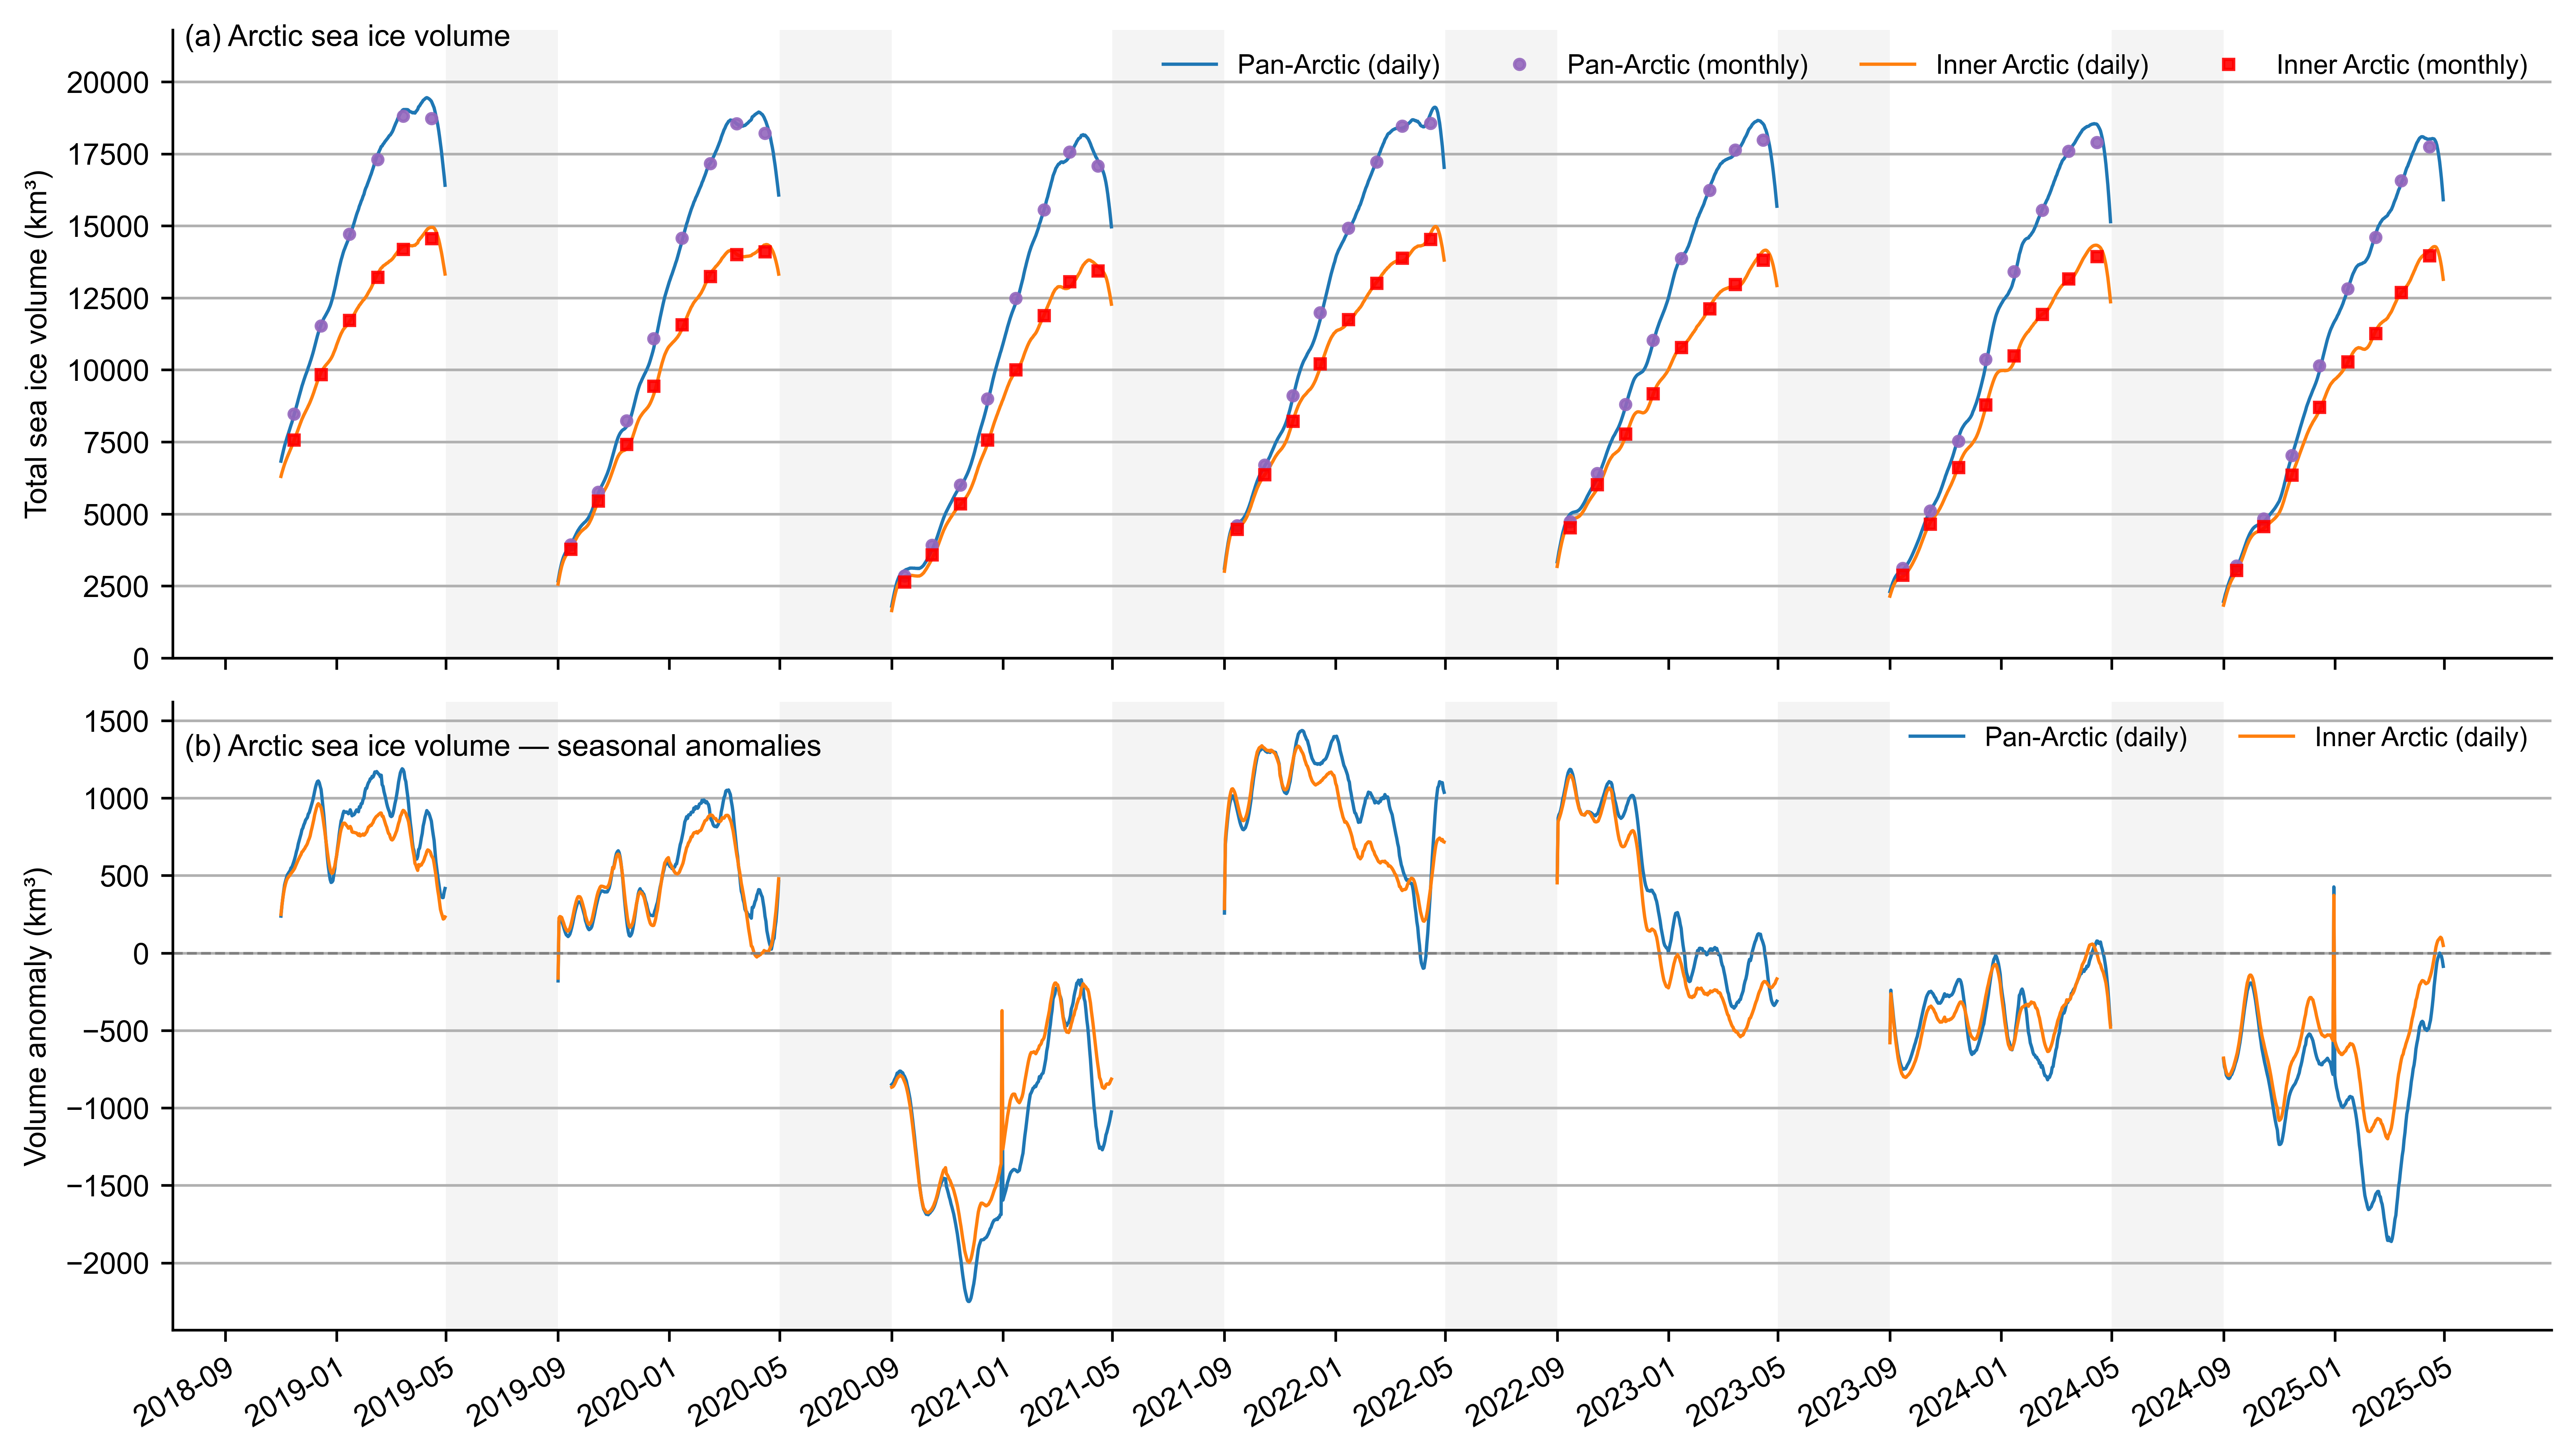

In [18]:
# Pan-Arctic + Inner Arctic Ocean volume; optional CS-2/SMOS overlay
_t0_vol = pd.Timestamp(
    min(volume_fused_daily.time.values[0], volume_fused_monthly.time.values[0])
)
_t1_vol = pd.Timestamp(
    max(volume_fused_daily.time.values[-1], volume_fused_monthly.time.values[-1])
)
_grid_start_vol = (
    pd.Timestamp(year=_t0_vol.year, month=9, day=1)
    if _t0_vol.month >= 9
    else pd.Timestamp(year=_t0_vol.year - 1, month=9, day=1)
)
all_days = pd.date_range(_grid_start_vol, _t1_vol, freq='D')
all_months = pd.date_range(_grid_start_vol, _t1_vol, freq='MS') + pd.Timedelta(days=14)

times_d = pd.to_datetime(all_days)


def _style_ts_axes(ax):
    ax.grid(axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9, 1, 5], bymonthday=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='both', labelsize=9)
    ax.yaxis.label.set_size(9)
    ax.xaxis.label.set_size(9)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')
        label.set_rotation_mode('anchor')


def _shade_summer(ax):
    for year in np.unique(times_d.year):
        for month in [5, 6, 7, 8]:
            start = pd.Timestamp(year=year, month=month, day=1)
            end = (
                pd.Timestamp(year=year, month=month + 1, day=1)
                if month < 12
                else pd.Timestamp(year=year + 1, month=1, day=1)
            )
            if start >= times_d.min() and start <= times_d.max():
                ax.axvspan(start, end, color='0.8', alpha=0.2, linewidth=0)


# Optional CS-2/SMOS overlay on raw panel
cs2 = SHOW_CS2SMOS

# --- Climatologies & anomalies: pan-Arctic ---
clim_v_monthly_pa = volume_fused_monthly.groupby(volume_fused_monthly.time.dt.month).mean('time')
v_anom_monthly_pa = (volume_fused_monthly - clim_v_monthly_pa.sel(
    month=volume_fused_monthly.time.dt.month
)).reindex(time=all_months)

clim_v_daily_pa = volume_fused_daily.groupby(volume_fused_daily.time.dt.dayofyear).mean('time')
v_anom_daily_pa = (volume_fused_daily - clim_v_daily_pa.sel(
    dayofyear=volume_fused_daily.time.dt.dayofyear
)).reindex(time=all_days).where(~np.isin(times_d.month, [5, 6, 7, 8]))

v_daily_pa = volume_fused_daily.reindex(time=all_days).where(
    ~np.isin(times_d.month, [5, 6, 7, 8])
)
v_monthly_pa = volume_fused_monthly.reindex(time=all_months)

# --- Climatologies & anomalies: inner Arctic ---
clim_v_monthly_iao = volume_fused_monthly_iao.groupby(volume_fused_monthly_iao.time.dt.month).mean('time')
v_anom_monthly_iao = (volume_fused_monthly_iao - clim_v_monthly_iao.sel(
    month=volume_fused_monthly_iao.time.dt.month
)).reindex(time=all_months)

clim_v_daily_iao = volume_fused_daily_iao.groupby(volume_fused_daily_iao.time.dt.dayofyear).mean('time')
v_anom_daily_iao = (volume_fused_daily_iao - clim_v_daily_iao.sel(
    dayofyear=volume_fused_daily_iao.time.dt.dayofyear
)).reindex(time=all_days).where(~np.isin(times_d.month, [5, 6, 7, 8]))

v_daily_iao = volume_fused_daily_iao.reindex(time=all_days).where(
    ~np.isin(times_d.month, [5, 6, 7, 8])
)
v_monthly_iao = volume_fused_monthly_iao.reindex(time=all_months)

# Printed write-up: monthly volume time series, monthly anomalies, daily max/min; CS-2 monthly if enabled
print('\n' + '=' * 70)
print('Sea ice volume — IS2SMGPSIT-V1 (write-up)')
print('=' * 70)

def _print_vol_monthly_extrema(label, monthly_da, daily_da):
    monthly_da = monthly_da.load()
    daily_da = daily_da.load()
    print(f'--- {label}: monthly means (km³) ---')
    for t, v in zip(pd.to_datetime(monthly_da.time.values), np.asarray(monthly_da.values).ravel()):
        if np.isfinite(v):
            print(f'  monthly mean volume   {t:%Y-%m-%d}   {v:,.2f} km³')
    vd = np.asarray(daily_da.values).ravel()
    td = pd.to_datetime(daily_da.time.values)
    if np.isfinite(vd).any():
        imax = int(np.nanargmax(vd))
        imin = int(np.nanargmin(vd))
        print(f'--- {label}: daily extrema (growth season; melt masked) ---')
        print(f'  daily max   {vd[imax]:,.2f} km³   on {td[imax]:%Y-%m-%d}')
        print(f'  daily min   {vd[imin]:,.2f} km³   on {td[imin]:%Y-%m-%d}')

_print_vol_monthly_extrema('Pan-Arctic', v_monthly_pa, v_daily_pa)
_print_vol_monthly_extrema('Inner Arctic Ocean', v_monthly_iao, v_daily_iao)

print('--- Pan-Arctic: monthly volume anomalies (km³) ---')
_v = v_anom_monthly_pa.load()
for t, v in zip(pd.to_datetime(_v.time.values), np.asarray(_v.values).ravel()):
    if np.isfinite(v):
        print(f'  monthly volume anom.  {t:%Y-%m-%d}   {v:+,.2f} km³')
print('--- Inner Arctic: monthly volume anomalies (km³) ---')
_v = v_anom_monthly_iao.load()
for t, v in zip(pd.to_datetime(_v.time.values), np.asarray(_v.values).ravel()):
    if np.isfinite(v):
        print(f'  monthly volume anom.  {t:%Y-%m-%d}   {v:+,.2f} km³')

def _print_daily_anom_extrema(label, daily_anom_da):
    daily_anom_da = daily_anom_da.load()
    vd = np.asarray(daily_anom_da.values).ravel()
    td = pd.to_datetime(daily_anom_da.time.values)
    if not np.isfinite(vd).any():
        return
    imax = int(np.nanargmax(vd))
    imin = int(np.nanargmin(vd))
    print(f'--- {label}: daily volume anomaly extrema (km³; melt masked) ---')
    print(f'  daily anom max   {vd[imax]:+,.2f} km³   on {td[imax]:%Y-%m-%d}')
    print(f'  daily anom min   {vd[imin]:+,.2f} km³   on {td[imin]:%Y-%m-%d}')

_print_daily_anom_extrema('Pan-Arctic', v_anom_daily_pa)
_print_daily_anom_extrema('Inner Arctic Ocean', v_anom_daily_iao)

if cs2:
    print('--- CS-2/SMOS v206 inner-Arctic monthly volume (km³) ---')
    for t, v in zip(pd.to_datetime(volume_awi.time.values), np.asarray(volume_awi.values).ravel()):
        if np.isfinite(v):
            print(f'  monthly (CS-2/SMOS)     {t:%Y-%m-%d}   {v:,.2f} km³')

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10.8, 6.12), sharex=True)

# Top: raw volume (daily lines + monthly markers)
v_daily_pa.plot(
    ax=ax0, color='C0', linewidth=1.0, label='Pan-Arctic (daily)', zorder=2,
)
v_monthly_pa.plot(
    ax=ax0,
    color='tab:purple',
    marker='o',
    markersize=3,
    linestyle='None',
    linewidth=0,
    label='Pan-Arctic (monthly)',
    alpha=0.9,
    zorder=3,
)
v_daily_iao.plot(
    ax=ax0, color='C1', linewidth=1.0, label='Inner Arctic (daily)', zorder=2,
)
v_monthly_iao.plot(
    ax=ax0,
    color='r',
    marker='s',
    markersize=3,
    linestyle='None',
    linewidth=0,
    label='Inner Arctic (monthly)',
    alpha=0.9,
    zorder=3,
)
if cs2:
    ax0.plot(
        volume_awi.time.values,
        volume_awi.values,
        color='c', linestyle='', linewidth=0, marker='^', markersize=3, alpha=0.9,
        label='CS-2/SMOS v206 inner Arctic (monthly)',
        zorder=3,
    )
ax0.set_xlabel('')
ax0.set_ylabel('Total sea ice volume (km³)')
ax0.set_ylim(0, 21800)
ax0.text(0.005, 1.01, '(a) Arctic sea ice volume',
         transform=ax0.transAxes, ha='left', va='top', fontsize=9)
ax0.legend(loc='upper right', frameon=False, ncol=5 if cs2 else 4, fontsize=8)
ax0.tick_params(axis='x', labelbottom=False)
_style_ts_axes(ax0)
_shade_summer(ax0)

# Bottom: daily anomalies only (pan-Arctic + inner Arctic; no monthly)
v_anom_daily_pa.plot(
    ax=ax1, color='C0', linewidth=1.0, label='Pan-Arctic (daily)', zorder=2,
)
v_anom_daily_iao.plot(
    ax=ax1, color='C1', linewidth=1.0, label='Inner Arctic (daily)', zorder=2,
)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_xlabel('')
ax1.set_ylabel('Volume anomaly (km³)')
ax1.text(0.005, 0.95, '(b) Arctic sea ice volume — seasonal anomalies',
         transform=ax1.transAxes, ha='left', va='top', fontsize=9)
ax1.legend(loc='upper right', frameon=False, ncol=2, fontsize=8)
_style_ts_axes(ax1)
_shade_summer(ax1)

plt.tight_layout()
plt.subplots_adjust(hspace=0.07)
_savename = 'arctic_sea_ice_volume_anomalies'
if cs2:
    _savename += '_cs2'
plt.savefig(f'../paper/figures/{_savename}.png', dpi=300)
plt.show()


## Inner Arctic Ocean mean thickness

IAO-focused IS2SMGPSIT-V1 time series (raw + seasonal anomalies). Set `SHOW_CS2SMOS = True` to optionally overlay CS-2/SMOS v206 monthly thickness.


In [ ]:
# IAO mean thickness: raw + seasonal anomalies; optional CS-2/SMOS overlay
clim_t_monthly_iao = thick_mean_monthly_iao.groupby(thick_mean_monthly_iao.time.dt.month).mean('time')
t_anom_monthly_iao = (thick_mean_monthly_iao - clim_t_monthly_iao.sel(
    month=thick_mean_monthly_iao.time.dt.month
)).reindex(time=all_months)
clim_t_daily_iao = thick_mean_daily_iao.groupby(thick_mean_daily_iao.time.dt.dayofyear).mean('time')
t_anom_daily_iao = (thick_mean_daily_iao - clim_t_daily_iao.sel(
    dayofyear=thick_mean_daily_iao.time.dt.dayofyear
)).reindex(time=all_days).where(~np.isin(times_d.month, [5, 6, 7, 8]))
t_daily_iao = thick_mean_daily_iao.reindex(time=all_days).where(
    ~np.isin(times_d.month, [5, 6, 7, 8])
)
t_monthly_iao = thick_mean_monthly_iao.reindex(time=all_months)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10.8, 6.12), sharex=True)
t_daily_iao.plot(ax=ax0, color='C1', linewidth=1.0, label='IS2SMGPSIT-V1 (daily)', zorder=2)
t_monthly_iao.plot(
    ax=ax0, color='r', marker='s', markersize=3,
    linestyle='None', linewidth=0, label='IS2SMGPSIT-V1 (monthly)', alpha=0.9, zorder=3,
)
if SHOW_CS2SMOS:
    ax0.plot(thickness_awi.time.values, thickness_awi.values,
             color='c', linestyle='', linewidth=0, marker='^', markersize=3, alpha=0.9,
             label='CS-2/SMOS v206 (monthly)', zorder=3)
ax0.set_xlabel('')
ax0.set_ylabel('Sea ice thickness (m)')
ax0.set_ylim(0, 2.41)
ax0.text(0.005, 1.01, '(a) Inner Arctic Ocean mean thickness',
         transform=ax0.transAxes, ha='left', va='top', fontsize=9)
ax0.legend(loc='upper right', frameon=False, ncol=3 if SHOW_CS2SMOS else 2, fontsize=8)
ax0.tick_params(axis='x', labelbottom=False)
_style_ts_axes(ax0)
_shade_summer(ax0)
t_anom_daily_iao.plot(ax=ax1, color='C1', linewidth=1.0, label='IS2SMGPSIT-V1 (daily)', zorder=2)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Thickness anomaly (m)')
ax1.set_xlabel('')
ax1.text(0.005, 0.95, '(b) Inner Arctic Ocean mean thickness — seasonal anomalies',
         transform=ax1.transAxes, ha='left', va='top', fontsize=9)
_style_ts_axes(ax1)
_shade_summer(ax1)
plt.tight_layout()
plt.subplots_adjust(hspace=0.07)
_suffix = '_cs2' if SHOW_CS2SMOS else ''
plt.savefig(f'../paper/figures/inner_arctic_seasonal_thickness_anomalies{_suffix}.png', dpi=300)
plt.show()


## Inner Arctic Ocean volume

IAO-focused IS2SMGPSIT-V1 volume time series (raw + seasonal anomalies). Set `SHOW_CS2SMOS = True` to optionally overlay CS-2/SMOS v206 monthly volume.


In [ ]:
# IAO volume: raw + seasonal anomalies; optional CS-2/SMOS overlay
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10.8, 6.12), sharex=True)
v_daily_iao.plot(ax=ax0, color='C1', linewidth=1.0, label='IS2SMGPSIT-V1 (daily)', zorder=2)
v_monthly_iao.plot(
    ax=ax0, color='r', marker='s', markersize=3,
    linestyle='None', linewidth=0, label='IS2SMGPSIT-V1 (monthly)', alpha=0.9, zorder=3,
)
if SHOW_CS2SMOS:
    ax0.plot(volume_awi.time.values, volume_awi.values,
             color='c', linestyle='', linewidth=0, marker='^', markersize=3, alpha=0.9,
             label='CS-2/SMOS v206 (monthly)', zorder=3)
ax0.set_xlabel('')
ax0.set_ylabel('Sea ice volume (km$^3$)')
ax0.text(0.005, 1.01, '(a) Inner Arctic Ocean total volume',
         transform=ax0.transAxes, ha='left', va='top', fontsize=9)
ax0.set_ylim(0, 16500)
ax0.legend(loc='upper right', frameon=False, ncol=3 if SHOW_CS2SMOS else 2, fontsize=8)
ax0.tick_params(axis='x', labelbottom=False)
_style_ts_axes(ax0)
_shade_summer(ax0)
v_anom_daily_iao.plot(ax=ax1, color='C1', linewidth=1.0, label='IS2SMGPSIT-V1 (daily)', zorder=2)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Volume anomaly (km$^3$)')
ax1.set_xlabel('')
ax1.text(0.005, 0.95, '(b) Inner Arctic Ocean volume — seasonal anomalies',
         transform=ax1.transAxes, ha='left', va='top', fontsize=9)
_style_ts_axes(ax1)
_shade_summer(ax1)
plt.tight_layout()
plt.subplots_adjust(hspace=0.07)
_suffix = '_cs2' if SHOW_CS2SMOS else ''
plt.savefig(f'../paper/figures/inner_arctic_seasonal_volume_anomalies{_suffix}.png', dpi=300)
plt.show()


## Pan-Arctic growth-season volume: winters overlaid

Monthly **pan-Arctic** total sea ice volume (`total_sea_ice_volume`) from IS2SMGPSIT-V1, with each **growth season** (Sep–Apr) overlaid on a common month axis—same idea as the thickness figure in notebook 11a and `plot_seasonal_growth_is2cs2_2024.py`. **IS2SMGPSIT-V1 only**.


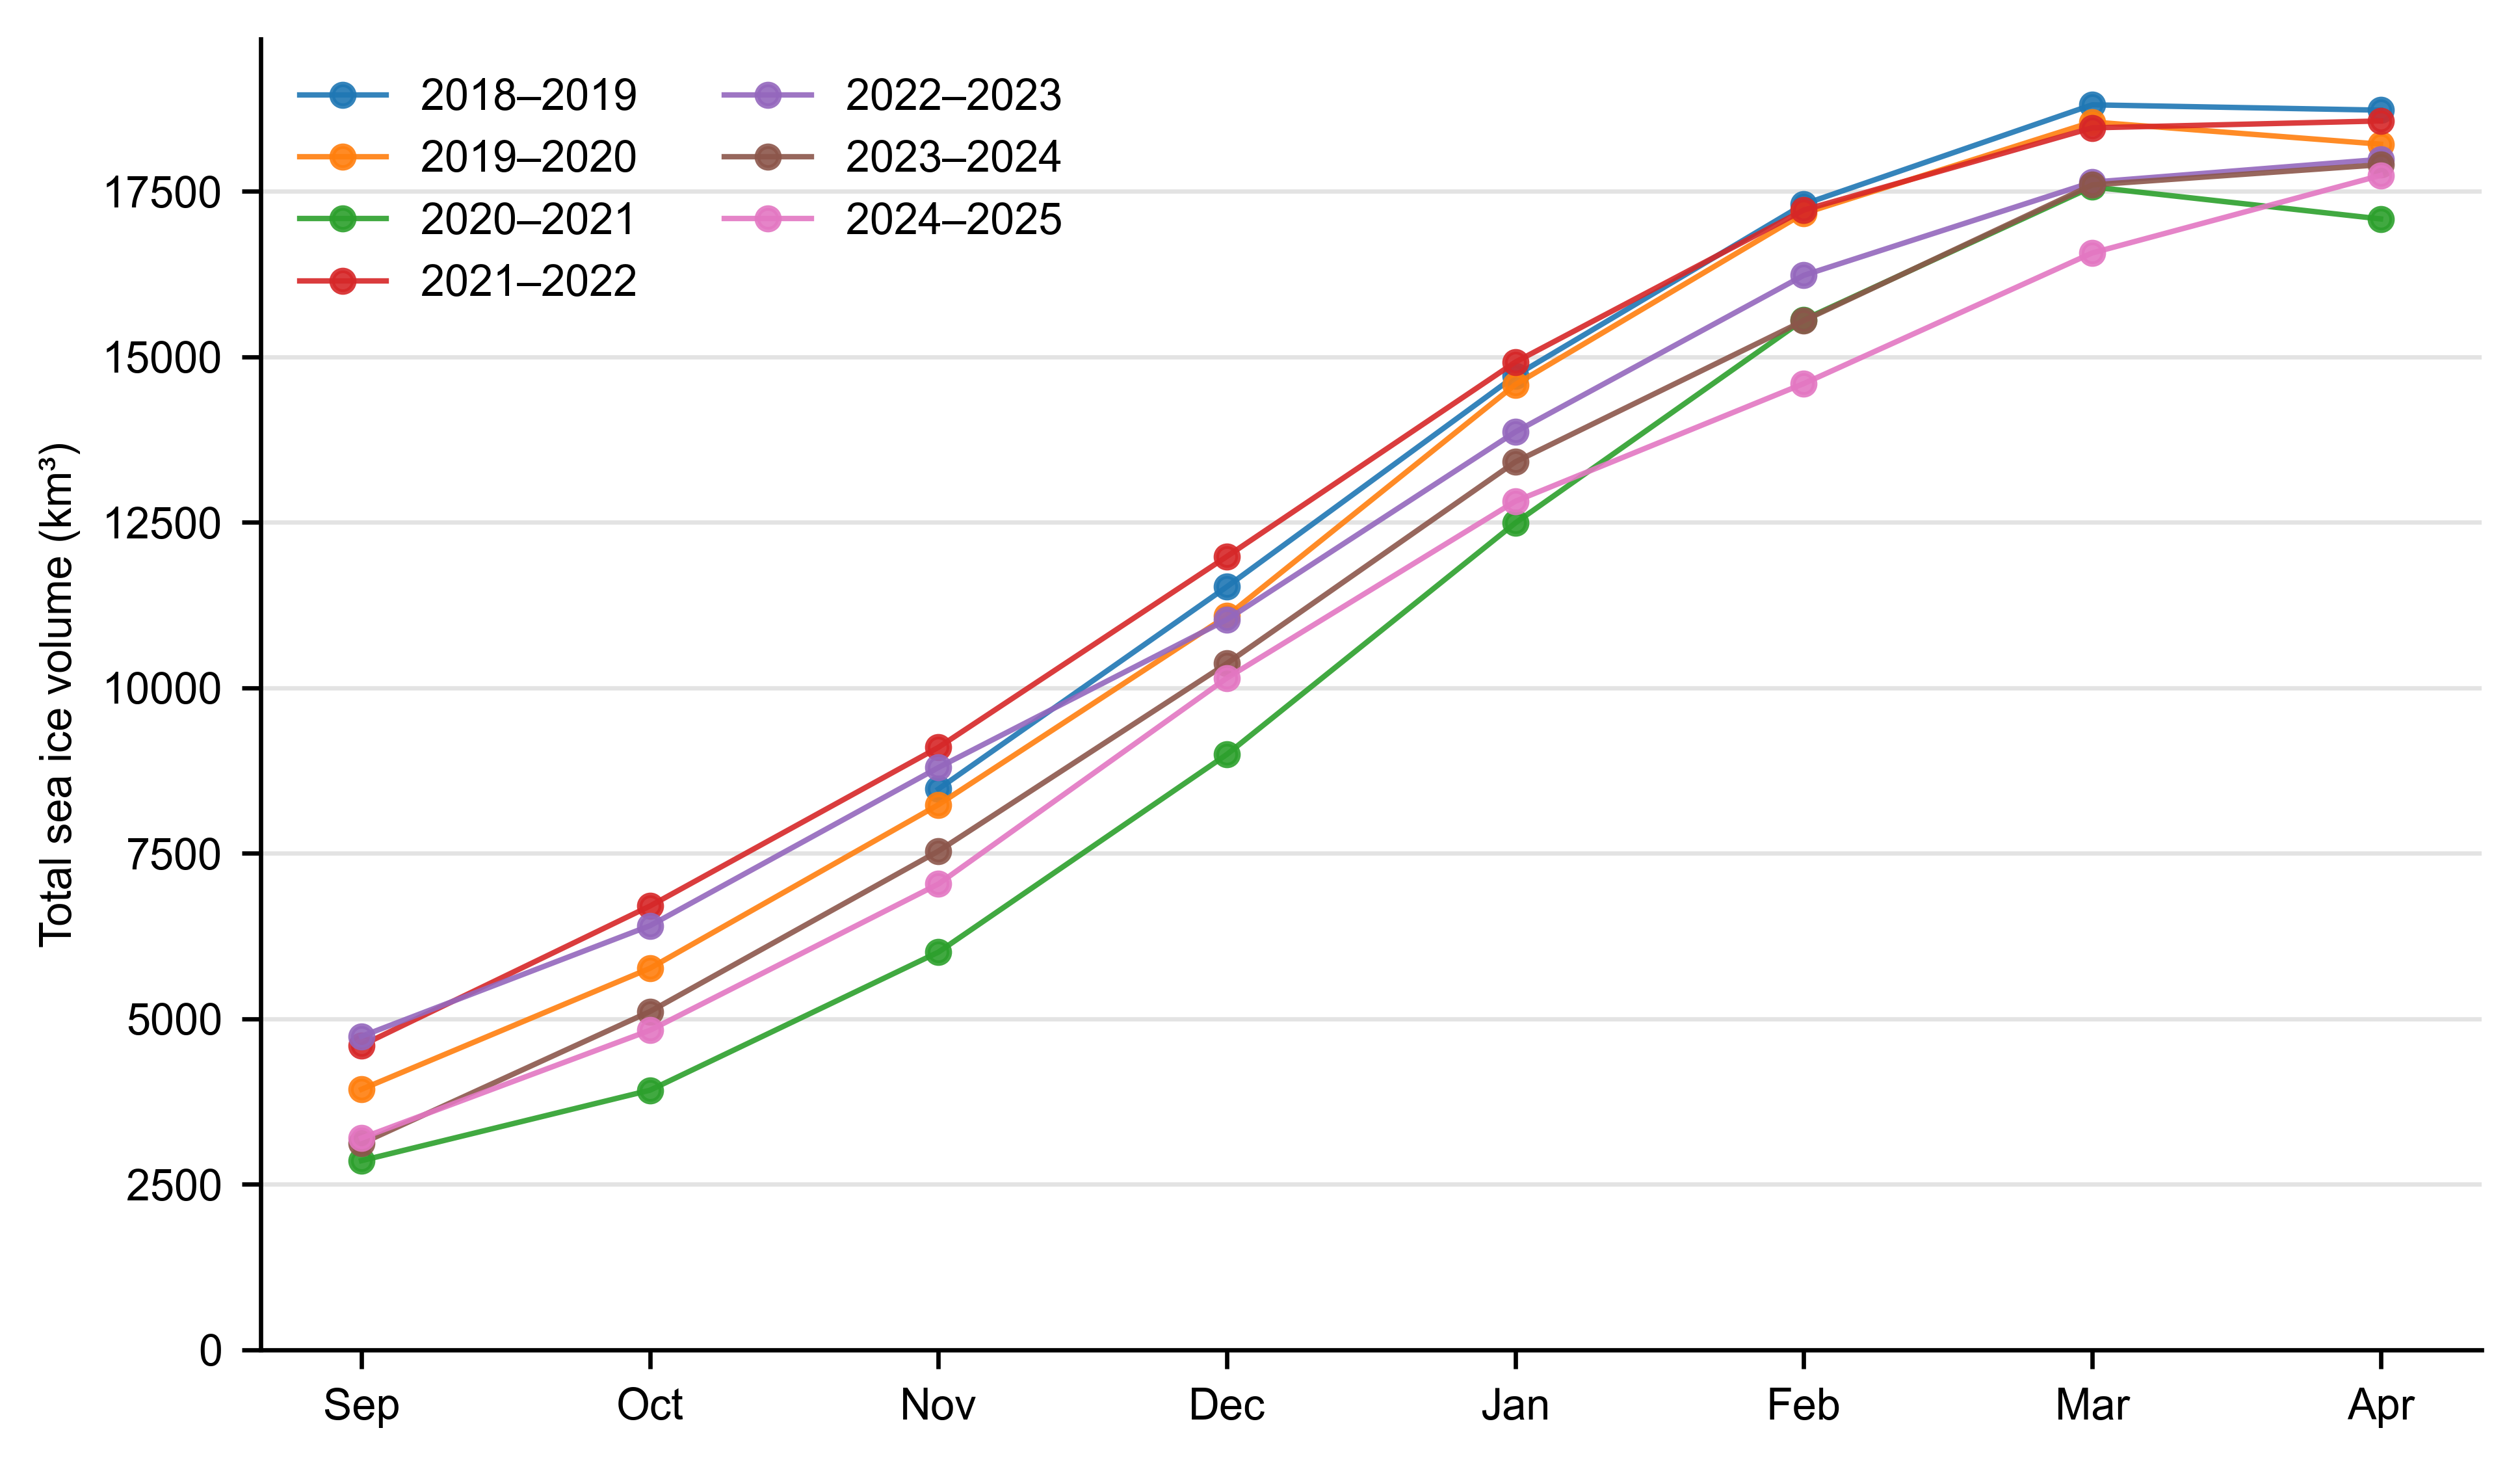

In [12]:
# Overlapping winters on a common Sep–Apr axis (IS2SMGPSIT-V1 pan-Arctic monthly volume)
_WINTER_MONTHS = [9, 10, 11, 12, 1, 2, 3, 4]
_WINTER_X = np.arange(len(_WINTER_MONTHS))
_WINTER_LABELS = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']


def _monthly_series_vol(da_monthly):
    return pd.Series(
        np.asarray(da_monthly.values).ravel(),
        index=pd.to_datetime(da_monthly.time.values),
    ).sort_index()


def _iter_winter_monthly_curves_vol(da_monthly):
    s = _monthly_series_vol(da_monthly.load())
    tmin, tmax = s.index.min(), s.index.max()
    start_oy = tmin.year if tmin.month >= 9 else tmin.year - 1
    end_oy = (tmax.year - 1) if tmax.month <= 4 else tmax.year
    curves = []
    for oy in range(start_oy, end_oy + 1):
        vals = []
        for m in _WINTER_MONTHS:
            yy = oy if m >= 9 else oy + 1
            hit = s[(s.index.year == yy) & (s.index.month == m)]
            vals.append(float(hit.iloc[0]) if len(hit) else np.nan)
        curves.append((f'{oy}–{oy + 1}', np.array(vals)))
    return curves


fig, ax = plt.subplots(figsize=(6.5, 3.8))
_curves_vol = _iter_winter_monthly_curves_vol(volume_fused_monthly)
_cmap = plt.get_cmap('tab10')
for _i, (_lab, _y) in enumerate(_curves_vol):
    ax.plot(
        _WINTER_X, _y, '-o', ms=4, lw=1.0,
        color=_cmap(_i % 10), label=_lab, alpha=0.9,
    )
ax.set_xticks(_WINTER_X)
ax.set_ylim(0, 19800)
ax.set_xticklabels(_WINTER_LABELS)
ax.set_ylabel('Total sea ice volume (km³)')
#ax.set_xlabel('Month (growth season)')

ax.grid(axis='y', alpha=0.35)
ax.legend(loc='upper left', ncol=2, frameon=False, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    '../paper/figures/pan_arctic_seasonal_volume_by_winter_is2v1.png',
    dpi=300,
)
plt.show()
